# 准备数据

In [1]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [3]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi300")

In [4]:
# 设置任务参数
name = "300_lgb"
index_symbol: str = "000300.SSE"
start: str = "2008-01-01"
end: str = "2023-12-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [5]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [6]:
# 加载模块
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_cs_norm
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [7]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [8]:
df

datetime,open,high,low,close,volume,turnover,open_interest,vwap,vt_symbol
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,str
2019-07-22 00:00:00,1.218633,1.297384,0.884943,1.0,6.0126e7,4.5648e9,0.0,75.920672,"""688008.SSE"""
2019-07-23 00:00:00,0.934597,1.052857,0.93433,0.989456,2.4642e7,1.7773e9,0.0,72.126821,"""688008.SSE"""
2019-07-24 00:00:00,0.989456,1.021756,0.967698,1.012813,2.2273e7,1.6103e9,0.0,72.296928,"""688008.SSE"""
2019-07-25 00:00:00,1.001068,1.067538,0.995728,1.04111,2.5385e7,1.9110e9,0.0,75.281034,"""688008.SSE"""
2019-07-26 00:00:00,1.024827,1.024827,0.938334,0.956754,1.7349e7,1.2401e9,0.0,71.477327,"""688008.SSE"""
…,…,…,…,…,…,…,…,…,…
2024-01-04 00:00:00,3.164205,3.188581,3.127641,3.149584,1.4594e7,1.8544432e8,0.0,12.706935,"""600372.SSE"""
2024-01-05 00:00:00,3.142261,3.164205,3.025245,3.042323,2.6664e7,3.3121762e8,0.0,12.421811,"""600372.SSE"""
2024-01-08 00:00:00,3.042323,3.0667,2.988681,2.993571,1.8761e7,2.28251935e8,0.0,12.166611,"""600372.SSE"""


In [9]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period = ("2008-01-01", "2014-12-31"),
    valid_period = ("2015-01-01", "2016-12-31"),
    test_period = ("2017-01-01", "2020-8-31"),
)

In [10]:
dataset.set_label("ts_delay(vwap, -3) / ts_delay(vwap, -1) - 1")

In [11]:
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))

In [12]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [13]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=6)

2026-10-06 08:12:45 开始计算表达式因子特征


100%|██████████| 159/159 [04:10<00:00,  1.58s/it]


2026-10-06 08:16:57 开始合并结果数据因子特征


0it [00:00, ?it/s]


2026-10-06 08:16:59 开始筛选成分股数据


100%|██████████| 819/819 [00:07<00:00, 114.43it/s]


In [14]:
# 特征表现分析
dataset.show_feature_performance("rsv_5")

In [15]:
# 数据预处理
dataset.process_data()

In [16]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [17]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.lgb_model import LgbModel

In [18]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [19]:
# 创建模型对象
model: AlphaModel = LgbModel(seed=42)

In [20]:
# 使用数据集训练模型
model.fit(dataset)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.246106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32146
[LightGBM] [Info] Number of data points in the train set: 491334, number of used features: 149
[LightGBM] [Info] Start training from score 0.000000
[1]	train's l2: 0.99464	valid's l2: 0.994928
Training until validation scores don't improve for 50 rounds
[2]	train's l2: 0.992978	valid's l2: 0.993516
[3]	train's l2: 0.991489	valid's l2: 0.992376
[4]	train's l2: 0.990221	valid's l2: 0.991527
[5]	train's l2: 0.989087	valid's l2: 0.990897
[6]	train's l2: 0.988004	valid's l2: 0.990354
[7]	train's l2: 0.987056	valid's l2: 0.989884
[8]	train's l2: 0.986171	valid's l2: 0.989494
[9]	train's l2: 0.985402	valid's l2: 0.989246
[10]	train's l2: 0.984544	valid's l2: 0.989039
[11]	train's l2: 0.98385	valid's l2: 0.988785
[12]	train's l2: 0.98312	valid's l2: 0.988506
[13]	train's l2: 0.982459	valid's l2: 0.98

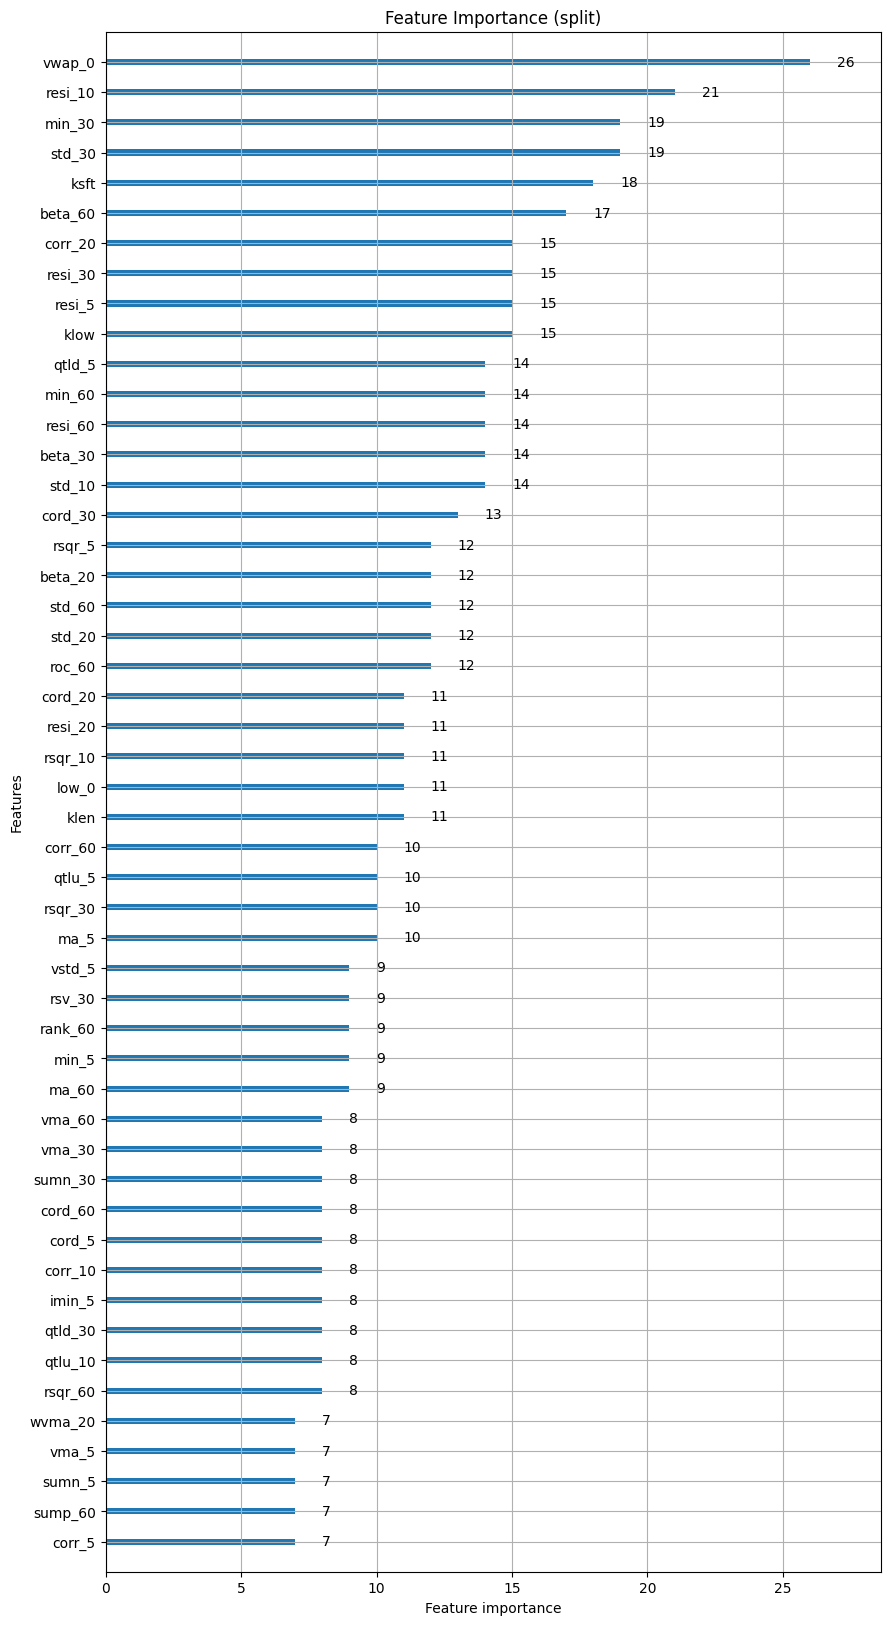

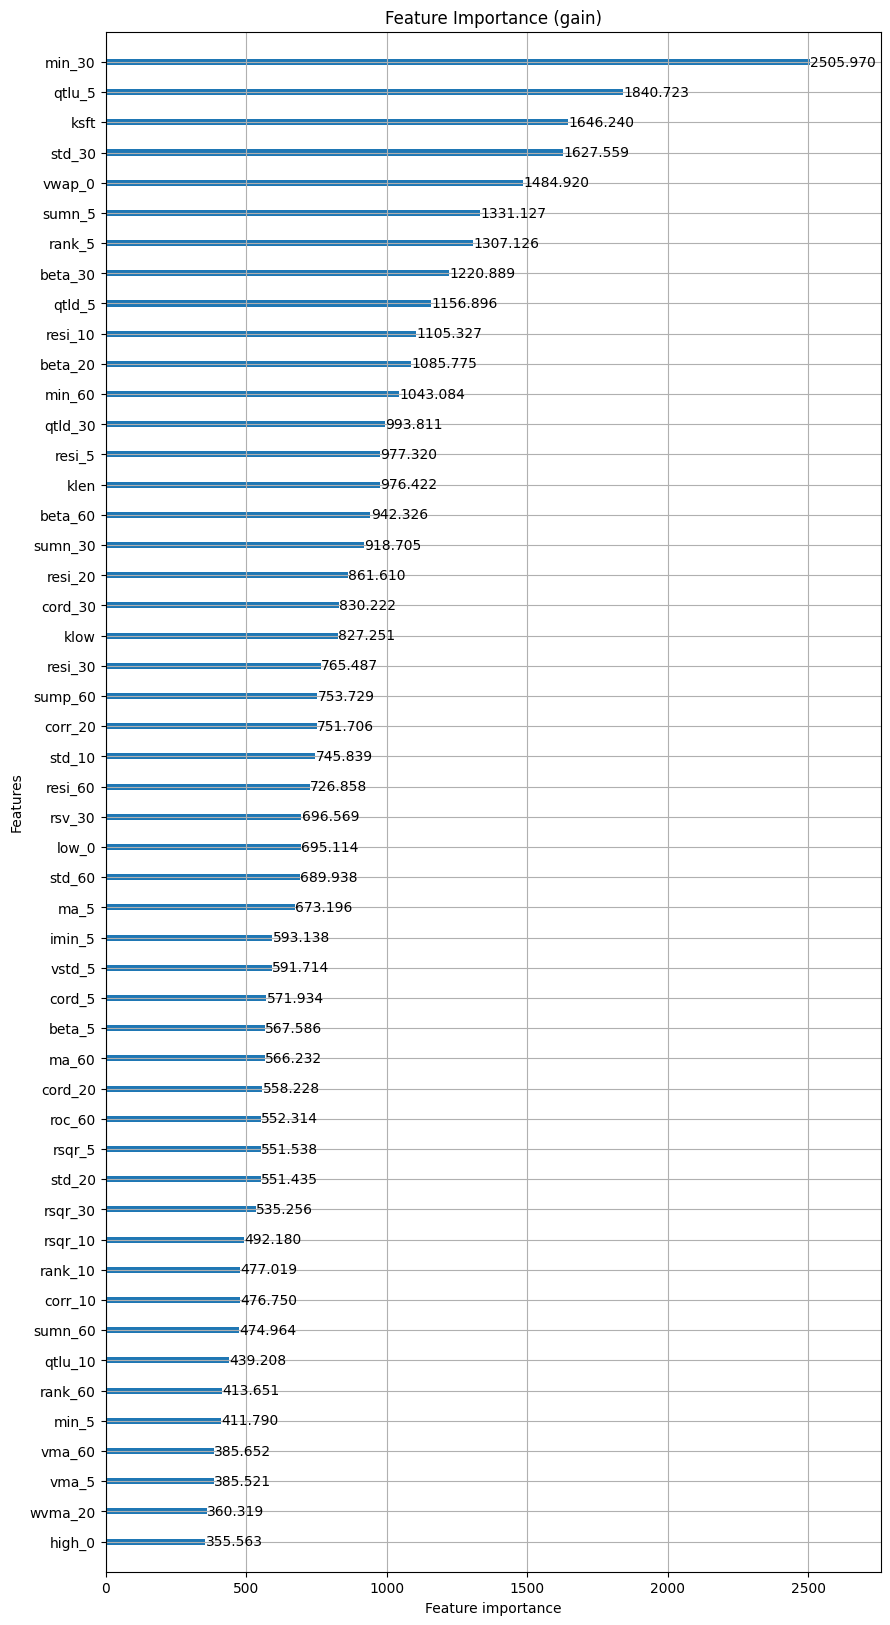

In [21]:
# 查看模型细节
model.detail()

In [22]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [23]:
model: AlphaModel = lab.load_model(name)

In [24]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

In [25]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [26]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [27]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [28]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [29]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [30]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2017, 1, 1),
    end=datetime(2020, 8, 1),
    capital=100000000,
    fill_price="vwap"
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [31]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2026-10-06 08:19:13 开始加载历史数据


100%|██████████| 819/819 [00:08<00:00, 97.31it/s] 

2026-10-06 08:19:21 部分合约历史数据为空：['300979.SZSE', '600938.SSE', '600832.SSE', '601995.SSE', '688303.SSE', '688041.SSE', '000527.SZSE', '300999.SZSE', '300919.SZSE', '001289.SZSE', '600087.SSE', '601868.SSE', '601268.SSE', '601728.SSE', '605117.SSE', '300896.SZSE', '601299.SSE', '600591.SSE', '000562.SZSE', '300957.SZSE', '601825.SSE', '688271.SSE', '600941.SSE', '600631.SSE', '600357.SSE', '688065.SSE', '300888.SZSE', '301269.SZSE', '600102.SSE', '600905.SSE', '688187.SSE', '688223.SSE', '605499.SSE', '000024.SZSE', '600001.SSE', '300866.SZSE', '600786.SSE', '601059.SSE']
2026-10-06 08:19:21 所有历史数据加载完成
2026-10-06 08:19:21 策略初始化完成
2026-10-06 08:19:21 开始回放历史数据


2026-10-06 08:19:28 历史数据回放结束
2026-10-06 08:19:28 开始计算逐日盯市盈亏
2026-10-06 08:19:29 逐日盯市盈亏计算完成
2026-10-06 08:19:29 开始计算策略统计指标
2026-10-06 08:19:29 ------------------------------
2026-10-06 08:19:29 首个交易日：  2017-01-03
2026-10-06 08:19:29 最后交易日：  2020-07-31
2026-10-06 08:19:29 总交易日：  871
2026-10-06 08:19:29 盈利交易日：  465
2026-10-06 08:19:29 亏损交易日：  405
2026-10-06 08:19:29 起始资金：  100,000,000.00
2026-10-06 08:19:29 结束资金：  213,177,173.69
2026-10-06 08:19:29 总收益率：  113.18%
2026-10-06 08:19:29 年化收益：  31.19%
2026-10-06 08:19:29 最大回撤:   -35,489,778.81
2026-10-06 08:19:29 百分比最大回撤: -23.30%
2026-10-06 08:19:29 最长回撤天数:   70
2026-10-06 08:19:29 总盈亏：  113,177,173.69
2026-10-06 08:19:29 总手续费：  15,998,340.63
2026-10-06 08:19:29 总成交金额：  21,358,566,680.81
2026-10-06 08:19:29 总成交笔数：  4514
2026-10-06 08:19:29 日均盈亏：  129,939.35
2026-10-06 08:19:29 日均手续费：  18,367.78
2026-10-06 08:19:29 日均成交金额：  24,521,890.56
2026-10-06 08:19:29 日均成交笔数：  5.182548794489093
2026-10-06 08:19:29 日均收益率：  0.10%
2026-10-06 08:19:29 收益标准差： 

In [32]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)